# 00 — Data pull

Phase 1 of the Brent/WTI regime-shift study. Pulls EIA daily spot series **RBRTE** (Brent) and **RWTC** (WTI), builds the cleaned spread frame, and saves it to `data/processed/spread.csv`.

This notebook is a thin wrapper around `scripts/pull_eia.py` so the pull logic lives in exactly one place (`make data` runs this notebook; the script is also runnable standalone). It then previews and plots the result as a reproducibility check.

**Requires:** `EIA_API_KEY` in `.env` (free registration at eia.gov/opendata).

In [1]:
# Shared style block (identical across all notebooks)
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

# Make the repo root importable so we can reuse scripts/pull_eia.py
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
print("repo root:", REPO)

repo root: /Users/charliecockerell/Documents/Codex/brent-wti-regime-shift


## Pull and build

`fetch_series` pages through the EIA API (it caps responses at 5,000 rows; the full daily history is ~9,700). `build_spread` merges Brent and WTI, drops the single non-positive price (negative WTI, 20 Apr 2020 — see note below), and computes log levels and the spread.

In [2]:
import os

from dotenv import load_dotenv

from scripts.pull_eia import RAW, PROCESSED, fetch_series, build_spread

load_dotenv(REPO / ".env")
api_key = os.environ.get("EIA_API_KEY")
assert api_key, "Set EIA_API_KEY in .env (free registration at eia.gov/opendata)."

RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

brent = fetch_series("RBRTE", api_key)
wti = fetch_series("RWTC", api_key)
brent.to_csv(RAW / "RBRTE.csv", index=False)
wti.to_csv(RAW / "RWTC.csv", index=False)

spread = build_spread(brent, wti)
spread.to_csv(PROCESSED / "spread.csv", index=False)

print(f"{len(spread):,} rows: {spread['date'].min().date()} \u2192 {spread['date'].max().date()}")

  dropped non-positive price: 2020-04-20 brent=17.36 wti=-36.98
9,730 rows: 1987-05-20 → 2026-05-26


## Preview

In [3]:
display(spread.head())
display(spread.tail())
display(spread[["brent", "wti", "spread"]].describe())

,date,brent,wti,log_brent,log_wti,spread,log_spread
0,1987-05-20,18.63,19.75,2.924773,2.983153,-1.12,-0.058380
1,1987-05-21,18.45,19.95,2.915064,2.993229,-1.50,-0.078165
2,1987-05-22,18.55,19.68,2.920470,2.979603,-1.13,-0.059133
3,1987-05-26,18.63,19.35,2.924773,2.962692,-0.72,-0.037919
4,1987-05-27,18.60,19.38,2.923162,2.964242,-0.78,-0.041080


,date,brent,wti,log_brent,log_wti,spread,log_spread
9725,2026-05-19,114.64,112.09,4.741797,4.719302,2.55,0.022495
9726,2026-05-20,108.93,101.69,4.690705,4.621929,7.24,0.068777
9727,2026-05-21,105.84,100.20,4.661929,4.607168,5.64,0.054760
9728,2026-05-22,106.90,100.35,4.671894,4.608664,6.55,0.063230
9729,2026-05-26,102.75,97.63,4.632299,4.581185,5.12,0.051114


,brent,wti,spread
count,9730.000000,9730.000000,9730.000000
mean,51.249617,49.558372,1.691245
std,32.838855,29.364650,5.376929
min,9.100000,8.910000,-22.180000
25%,19.530000,20.982500,-1.610000
50%,46.140000,45.840000,-0.650000
75%,74.840000,72.020000,3.710000
max,143.950000,145.310000,29.590000


### Data note — negative WTI (20 Apr 2020)

On 20 Apr 2020, WTI spot settled at **−$36.98** as COVID demand collapse met Cushing storage saturation — a genuine historic print, not a data error. `log(price)` is undefined for non-positive values and the cointegration analysis runs on log levels, so `build_spread` drops this single observation from the processed series (the raw `RWTC.csv` keeps it). It is the only excluded row and is flagged in the paper's Limitations. The check below confirms it is absent from the processed frame.

In [4]:
import pandas as pd

raw_wti = pd.read_csv(RAW / "RWTC.csv", parse_dates=["date"])
print("raw RWTC min (should be negative, ~ -36.98):", raw_wti["rwtc"].min())
print("processed wti min (should be positive):    ", spread["wti"].min())
print("non-positive prices in processed frame:    ",
      int(((spread["brent"] <= 0) | (spread["wti"] <= 0)).sum()))
print("NaNs in processed frame:                   ", int(spread.isna().sum().sum()))

raw RWTC min (should be negative, ~ -36.98): -36.98
processed wti min (should be positive):     8.91
non-positive prices in processed frame:     0
NaNs in processed frame:                    0


## Plots

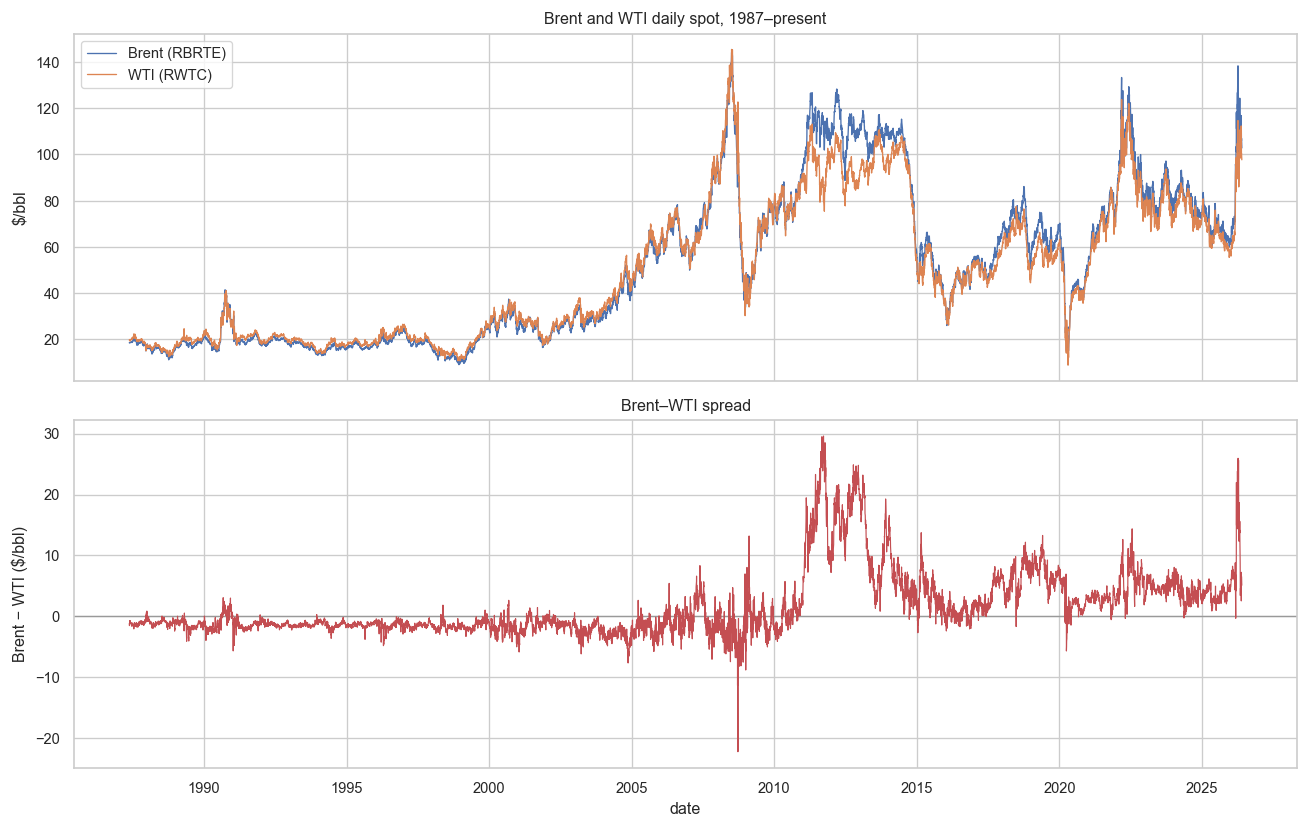

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(spread["date"], spread["brent"], label="Brent (RBRTE)", lw=0.8)
axes[0].plot(spread["date"], spread["wti"], label="WTI (RWTC)", lw=0.8)
axes[0].set_ylabel("$/bbl")
axes[0].set_title("Brent and WTI daily spot, 1987\u2013present")
axes[0].legend(loc="upper left")

axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].plot(spread["date"], spread["spread"], color="C3", lw=0.7)
axes[1].set_ylabel("Brent \u2212 WTI ($/bbl)")
axes[1].set_title("Brent\u2013WTI spread")
axes[1].set_xlabel("date")

fig.tight_layout()
plt.show()

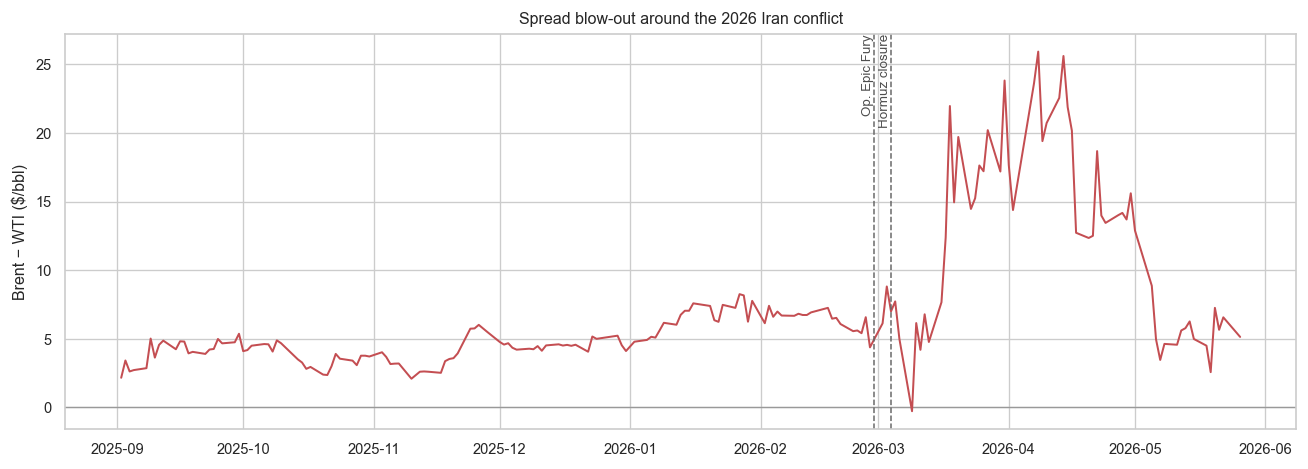

In [6]:
# Zoom: the 2026 regime shift (focal event 28 Feb 2026, Hormuz closure 4 Mar 2026)
window = spread[spread["date"] >= "2025-09-01"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(window["date"], window["spread"], color="C3", lw=1.2)
for d, lab in [("2026-02-28", "Op. Epic Fury"), ("2026-03-04", "Hormuz closure")]:
    ax.axvline(pd.Timestamp(d), color="0.4", ls="--", lw=0.9)
    ax.text(pd.Timestamp(d), ax.get_ylim()[1], lab, rotation=90,
            va="top", ha="right", fontsize=8, color="0.3")
ax.set_ylabel("Brent \u2212 WTI ($/bbl)")
ax.set_title("Spread blow-out around the 2026 Iran conflict")
fig.tight_layout()
plt.show()

Output: `data/processed/spread.csv` — consumed by `01_cointegration.ipynb`.